In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


In [19]:
file_path = "C:\\Users\\USER\\OneDrive\\Documents\\GitHub\\Research-Project\\backend\\lstm_stock_prediction\\data\\processed\\Annual.csv"

# The file is actually an Excel file (.xls), not a CSV
# Skip the first 4 rows and use row 4 (index 4) as the header
data = pd.read_excel(file_path, skiprows=4)

# The first row after skiprows should contain the actual column names
# Let's set the first row as column names
data.columns = data.iloc[0]
data = data[1:]  # Remove the first row since it's now the header

# Reset index
data = data.reset_index(drop=True)

# Drop columns that are None or NaN
data = data.loc[:, data.columns.notna()]

# Remove rows where first column is NaN (category headers)
first_col = data.columns[0]
data = data[data[first_col].notna()]

# Drop "MAIN TYPE" and "SUB TYPE" columns
columns_to_drop = [col for col in data.columns if col in ['MAIN TYPE', 'SUB TYPE']]
if columns_to_drop:
    data = data.drop(columns=columns_to_drop)
    print(f"Dropped columns: {columns_to_drop}")

# Remove all rows with any NaN values
data = data.dropna()

# Reset index again
data = data.reset_index(drop=True)

print(f"\nFinal shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

# Set pandas display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Display with styling
data.head(15).style.set_properties(**{
    'text-align': 'left',
    'white-space': 'nowrap'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
])

Dropped columns: ['MAIN TYPE', 'SUB TYPE']

Final shape: (295, 9)
Columns: ['COMPANY NAME', 'OPEN (Rs.)', 'CLOSE  (Rs.)', 'CHANGE %', 'HIGHEST (Rs.)', 'LOWEST (Rs.)', 'TURNOVER (Rs.)', 'SHARES (No.)', 'TRADES (No.)']


0,COMPANY NAME,OPEN (Rs.),CLOSE (Rs.),CHANGE %,HIGHEST (Rs.),LOWEST (Rs.),TURNOVER (Rs.),SHARES (No.),TRADES (No.)
0,KELANI TYRES,63.500000,70,10.236200,71.100000,61,53058673.700000,805925,1022
1,AMANA BANK,2.300000,2.200000,-4.347800,2.300000,1.900000,108925202.400000,51047754,2107
2,CARGILLS BANK,0,7.900000,0,8.200000,7.500000,207245925.900000,26182400,3823
3,COMMERCIAL BANK,95.500000,97.700000,2.303700,98.600000,0,1502239357,16383980,5353
4,COMMERCIAL BANK,80.400000,85.200000,5.970100,86,73.500000,118122661,1445753,1824
5,DFCC BANK PLC,79.600000,76,-4.522600,80,65.700000,831476446,11437957,4618
6,HDFC,31.600000,32,1.265800,33.800000,28.100000,5023322.100000,161441,497
7,HNB,169.250000,180,6.351600,182,151,2242304691.250000,13534679,3681
8,HNB,140,150.250000,7.321400,152,128.750000,191789381.250000,1362998,1723
9,NAT. DEV. BANK,64.900000,68,4.776600,68.700000,0,1503212924.300000,23399057,6474


In [20]:
data.shape

(295, 9)

In [21]:
data.isnull().sum()


0
COMPANY NAME      0
OPEN (Rs.)        0
CLOSE  (Rs.)      0
CHANGE %          0
HIGHEST (Rs.)     0
LOWEST (Rs.)      0
TURNOVER (Rs.)    0
SHARES (No.)      0
TRADES (No.)      0
dtype: int64

In [22]:
## to describe the dataset
data.describe()

,COMPANY NAME,OPEN (Rs.),CLOSE (Rs.),CHANGE %,HIGHEST (Rs.),LOWEST (Rs.),TURNOVER (Rs.),SHARES (No.),TRADES (No.)
count,295,295.0,295,295,295.0,295,295.0,295,295
unique,269,254.0,249,269,241.0,221,295.0,295,278
top,TESS AGRO,0.3,23,0,0.1,0,8358587.9,1583272,629
freq,4,3.0,5,16,5.0,6,1.0,1,3


Available columns in data:
['COMPANY NAME', 'OPEN (Rs.)', 'CLOSE  (Rs.)', 'CHANGE %', 'HIGHEST (Rs.)', 'LOWEST (Rs.)', 'TURNOVER (Rs.)', 'SHARES (No.)', 'TRADES (No.)']

Using column: 'CLOSE  (Rs.)'


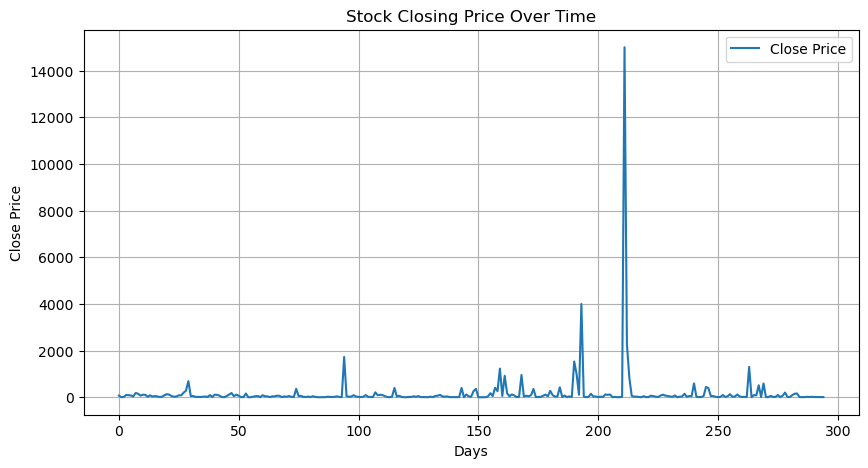

In [26]:
# First check the exact column names
print("Available columns in data:")
print(data.columns.tolist())

# Use the correct column name (check the output above for exact spelling)
close_col = [col for col in data.columns if 'CLOSE' in str(col).upper()][0]
print(f"\nUsing column: '{close_col}'")

plt.figure(figsize=(10,5))
plt.plot(data[close_col], label='Close Price')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

Available columns:
  'COMPANY NAME'
  'OPEN (Rs.)'
  'CLOSE  (Rs.)'
  'CHANGE %'
  'HIGHEST (Rs.)'
  'LOWEST (Rs.)'
  'TURNOVER (Rs.)'
  'SHARES (No.)'
  'TRADES (No.)'

Using columns:
  Open: 'OPEN (Rs.)'
  High: 'HIGHEST (Rs.)'
  Low: 'LOWEST (Rs.)'
  Close: 'CLOSE  (Rs.)'


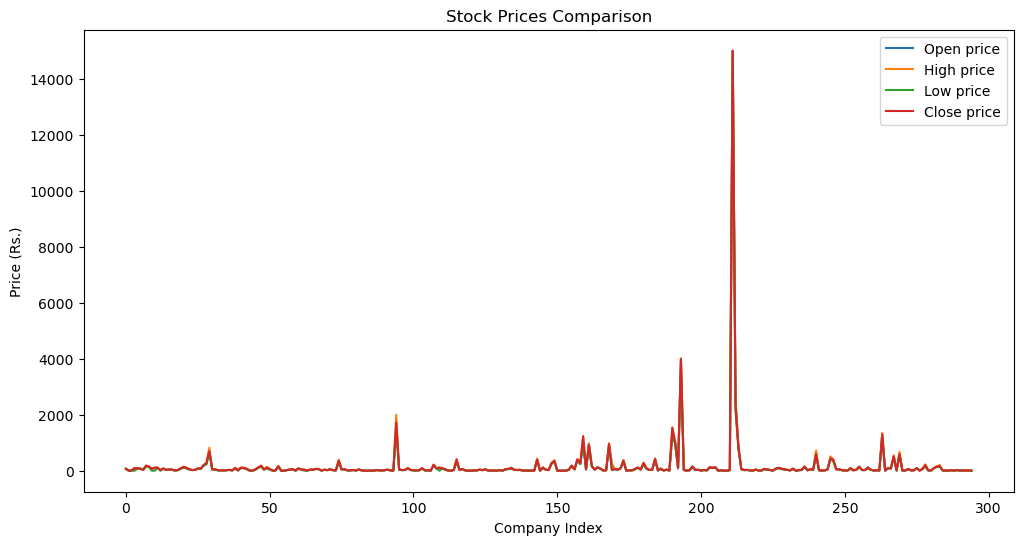

In [28]:
## Visualize the open price, close price, high price, low price and turnover for the company

# Print available columns to check exact names
print("Available columns:")
for col in data.columns:
    print(f"  '{col}'")

# Dynamically find the correct column names
open_col = [col for col in data.columns if 'OPEN' in str(col).upper()][0]
high_col = [col for col in data.columns if 'HIGH' in str(col).upper()][0]
low_col = [col for col in data.columns if 'LOW' in str(col).upper()][0]
close_col = [col for col in data.columns if 'CLOSE' in str(col).upper()][0]

print(f"\nUsing columns:")
print(f"  Open: '{open_col}'")
print(f"  High: '{high_col}'")
print(f"  Low: '{low_col}'")
print(f"  Close: '{close_col}'")

open_price = data[open_col]
high_price = data[high_col]
low_price = data[low_col]
close_price = data[close_col]

plt.figure(figsize=(12,6))

plt.plot(open_price, label='Open price')
plt.plot(high_price, label='High price')
plt.plot(low_price, label='Low price')
plt.plot(close_price, label='Close price')

plt.legend()
plt.xlabel("Company Index")
plt.ylabel("Price (Rs.)")
plt.title("Stock Prices Comparison")
plt.show()